This notebook use the <a href="https://link-to-repo-multimin">Multimin package</a> to fit the distribution of Near Earth Objects from the <a href="https://ssd.jpl.nasa.gov/tools/sbdb_query.html"> Small-Body Database Query JPL Horizons</a> 

In [16]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import multimin as mm
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [10]:
df = pd.read_csv("../datos/full_orbital_elements.csv")  #The csv file that contains the orbital elements resulting of the three catalogs.
neas = df[df["q"] < 1.30]  #we filter the NEAs orbits
neas["i"] = neas["i"]*np.pi/180 
neas

,q,e,i,om,w,ma,a
0,1.133158,0.222800,0.189019,304.2900,178.910,222.760000,1.45800
1,1.194108,0.547000,0.202109,183.8500,156.230,56.290000,2.63600
2,1.060735,0.570900,0.164061,110.4200,350.470,238.760000,2.47200
3,1.245289,0.532900,0.465828,215.5000,132.480,276.420000,2.66600
4,1.082892,0.435700,0.207345,171.3200,26.650,123.530000,1.91900
...,...,...,...,...,...,...,...
34739,0.245422,0.868818,0.094379,155.3910,308.896,343.948006,1.87085
34740,0.918162,0.533916,0.296701,149.5070,222.657,347.943308,1.96995
34741,0.282196,0.842836,0.069599,122.8250,305.320,342.332825,1.79555
34742,0.520936,0.688197,0.146875,112.3790,281.271,337.895303,1.67072


Let's begin visualizating the a, e, i distribution plot 

In [12]:
data_neas = np.array(neas[["q","e","i"]])

original_q = data_neas[:,0]
original_e = data_neas[:,1]
original_i = data_neas[:,2]*180/np.pi

fig = go.Figure()

# NEOS
fig.add_trace(go.Splom(
    dimensions=[
        dict(label='q [au]', values=original_q),
        dict(label='e', values=original_e),
        dict(label='i [°]', values=original_i)
    ],
    showupperhalf=False,
    diagonal_visible=False,
    marker=dict(color="#6baed6", size=3)
))

# Layout minimalista
fig.update_layout(
    title='Orbital elements (q,e,i) of Near Earth Asteroids',
    title_x=0.5,
    width=650,
    height=650,
    font=dict(family="Arial", color="#444444", size=14),
    plot_bgcolor='white',
    paper_bgcolor='white',
    dragmode='select',
    hovermode='closest',
    legend=dict(
        x=0.8, y=1.05,
        bgcolor='rgba(0,0,0,0)',
        borderwidth=0
    )
)

# Ajuste de ejes para estilo limpio
for axis in ['xaxis', 'xaxis2', 'xaxis3', 'yaxis', 'yaxis2', 'yaxis3']:
    fig.update_layout({axis: dict(
        showline=True,
        linewidth=1,
        linecolor="#333333",
        mirror=True,
        showgrid=True,
        gridcolor="#e6e6e6",
        zeroline=False
    )})

fig.show()

In [13]:
# First, we need to transform the data into an unbounded and scaled space in order to apply 
# a normal distribution. Since the domain of the normal distribution is infinite, 
# we must map the original bounded data to an unbounded space.

scales=[1.30,1.00,np.pi]  #we define the scales of the data
udata=np.zeros_like(data_neas)
for i in range(len(data_neas)):
    udata[i]=mm.Util.tIF(data_neas[i],scales,mm.Util.f2u)  #we perform the transformation
udata    

array([[ 1.9157137 , -1.24942321, -2.74858407],
       [ 2.42273504,  0.18855668, -2.67718139],
       [ 1.48914664,  0.28552407, -2.89861195],
       ...,
       [-1.28280159,  1.67948255, -3.78733156],
       [-0.40246758,  0.79170356, -3.0150243 ],
       [ 0.01043796,  0.41166897, -3.18995763]], shape=(34744, 3))

C:\Users\aguju\Documents\tesis\juanita\juanita\repo_public\quasiNEA\multimin.py:255: UserWarning:

The figure layout has changed to tight



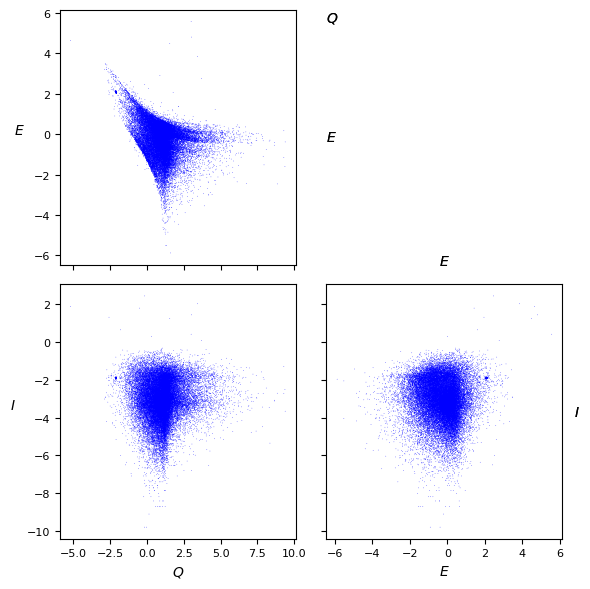

In [14]:
#Let's visualize the unbounded distribution after apply the trasformation 

properties=dict(
    Q=dict(label=r"$Q$",range=None),
    E=dict(label=r"$E$",range=None),
    I=dict(label=r"$I$",range=None),
)
G=mm.PlotGrid(properties,figsize=3)

sargs=dict(s=0.2,edgecolor='None',color='b')
hist=G.scatterPlot(udata,**sargs)

In [15]:
#we want to fit the data to a CMND with 10 gaussians and 3 variables
Ngauss = 10
Nvars = 3

F=mm.FitCMND(Ngauss=Ngauss,Nvars=Nvars)

t = mm.Util.elTime(0)
F.fitData(udata,verbose=False,advance=1)
t = mm.Util.elTime()
print(f"-log(L)/N = {F.solution.fun/len(udata)}")

[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5]
Iterations:
Iter 0:
	Vars: [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 2.9, 1.8, -1.7, 2.8, 1.8, -1.7, 2.8, 1.8, -1.7, 2.8, 1.7, -1.7, 2.8, 1.7, -1.7, 2.8, 1.7, -1.7, 2.8, 1.7, -1.6, 2.7, 1.7, -1.6, 2.7, 1.7, -1.6, 2.7, 1.7, -1.6, -1.2, -1.2, -1.8, -1.3, -1.2, -1.7, -1.3, -1.2, -1.7, -1.3, -1.3, -1.6, -1.3, -1.3, -1.6, -1.3, -1.3, -1.6, -1.3, -1.3, -1.5, -1.3, -1.3, -1.5, -1.3, -1.3, -1.5, -0.98, -1.3, -2, 4.3, 1.6, 1.7, 3.2, 1.9, 2, 2.7, 2.2, 2.1, 2, 2.7, 1.9, 1.4, 1.2, 2.1, 2.1, 1.9, 1.8, 1.4, 1.5, 1.7, 1.9, 1.7, 1.6, 1.5, 1.5, 1.5, 0.91, 1.1, 1.7]
	LogL/N: 5.538791794348295


C:\Users\aguju\Documents\tesis\juanita\juanita\repo_public\quasiNEA\multimin.py:1100: RuntimeWarning:

divide by zero encountered in log



Iter 1:
	Vars: [-2.9, 0.72, 1.8, -0.58, -2.6, 47, 2.8, 75, 45, 0.089, 3.2, -0.071, -1.9, 2.9, 0.57, -2.4, 2.5, 0.57, -2.6, 1.7, -0.15, -2.2, 0.22, 0.78, -5.4, 1.9, 0.53, -2.7, 1.3, 0.43, -2.6, 1.7, 0.4, -2.7, 1.4, 0.35, -2.7, 1.3, 0.33, -2.3, -0.9, -4.2, -1.9, -1, -2.6, -1.9, -1.5, -2.2, -2.1, -2.7, -2.3, -2.2, -2.4, -2.8, -1.5, -2.1, -2.5, -1.6, -3.2, -1.6, -1.9, -1.5, -1.9, -2.1, -1.6, -1.7, -1.7, -1.1, -1.3, -2.1, 0.7, -0.037, 1.1, 0.55, 0.79, 0.83, 1, 0.68, -0.28, 2, 1.3, 0.57, 0.41, 0.11, 1.8, 1.1, 1.5, 1.8, 1.2, 1.3, 0.89, 0.78, 0.5, 0.074, 0.53, 0.75, 1.2, 0.17, 0.72, 1.2]
	LogL/N: 4.711643354577249
Iter 2:
	Vars: [-2.9, -71, -1.1e+02, 73, -2, 47, 1.2, 75, 45, -1.1, 2.4, -0.19, -3, 2.9, 0.57, -2.4, 2.5, 0.57, -2.6, 1.2, -0.6, -2.9, 0.069, 0.36, -3.9, 0.84, 0.047, -3.5, 1.4, -0.84, -3.1, 1, -0.36, -2.7, 0.69, 0.05, -2.9, 0.98, -0.15, -2.4, -1.4, -4.1, -3, -1, -2.6, -1.9, -1.5, -2.2, -2.1, -2.9, -2.6, -2.3, -2.8, -3.3, -1.6, -2.9, -3, -1.9, -3.2, -2.3, -1.9, -2, -3, -2.4, -1.8, -2

We can plot both the fitted distribution and the original data distribution to evaluate the goodness of fit. Initially, we observe that the fitted distribution based on a simple three-dimensional normal distribution does not capture the shape of the original data accurately. Let's now construct a CMND using a larger number of Gaussian components and analyze how the fit improves.

C:\Users\aguju\Documents\tesis\juanita\juanita\repo_public\quasiNEA\multimin.py:255: UserWarning:

The figure layout has changed to tight



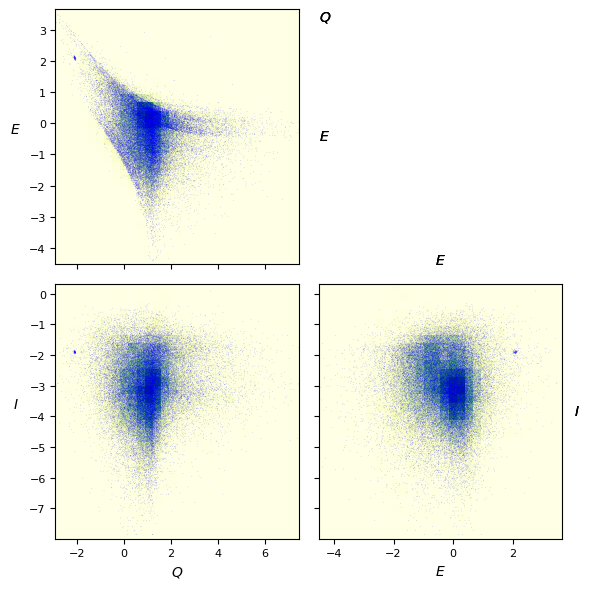

In [17]:
props=["Q","E","I"]
hargs=dict(bins=30,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='b',alpha=0.4)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

Using 10 Gaussian components results in a significantly better fit, but at a higher computational cost. While fitting a single Gaussian takes about 2 seconds, fitting with 10 Gaussians can take nearly 5 minutes.

In [18]:
#we can get the fit parameters
print(F.cmnd)

Composition of Ngauss = 10 gaussian multivariates of Nvars = 3 random variables:
    Weights: [0.11244919785175604, 1.7347064777527853e-32, 2.4071939461711755e-47, 0.14758483102076764, 0.0752875053584068, 0.14758483102076764, 0.1292466028008301, 0.14758483102076764, 0.14758483102076764, 0.09267736990593661]
    Number of variables: 3
    Averages (μ): [[2.3734146818942707, -0.00109242043587653, -3.007788941981905], [2.933425261505761, 0.5736009477123964, -2.368792024054989], [2.5180070116177724, 0.566177095139524, -2.5967239544964906], [0.534883057671901, -1.093008290491727, -3.079468553161005], [0.83987987508815, 0.5631187987269282, -3.780875893274352], [1.178612295689527, 0.152805396698645, -3.4426568839101654], [1.1262576276434748, -1.0500176687296703, -3.741720462197956], [0.9981524972777567, -0.464973517429018, -2.669437265515282], [0.25812062684790676, 0.31878510477211824, -2.9063689262213916], [1.467643659791944, -0.5072808367065654, -1.7261160007465406]]
    Standard deviations

In [19]:
#we save the fit in a pickle file
F.saveFit(f"products/fit-NEAS-Ngauss{Ngauss}.pkl",useprefix=False)

In [23]:
#we also can generate a sample from the fit to check the fit
N = int(1e4)
fit_sample =F.cmnd.rvs(Nsam=N)

#The random sample is in the unbounded space, so we need to convert it to the original space
converted_sample = np.zeros_like(fit_sample)
for i, element in enumerate(fit_sample):
    converted_sample[i] = mm.Util.tIF(element, scales, mm.Util.u2f)

In [26]:
q_fit = converted_sample[:,0]
e_fit = converted_sample[:,1]
i_fit = converted_sample[:,2]*180/np.pi

fig = go.Figure()

# NEOS
fig.add_trace(go.Splom(
    dimensions=[
        dict(label='q [au]', values=q_fit),
        dict(label='e', values=e_fit),
        dict(label='i [°]', values=i_fit)
    ],
    showupperhalf=False,
    diagonal_visible=False,
    marker=dict(color="#6baed6", size=2)
))

# Layout minimalista
fig.update_layout(
    title='Orbital Elements Generated Using 10 CMND',
    title_x=0.5,
    width=650,
    height=650,
    font=dict(family="Arial", color="#444444", size=14),
    plot_bgcolor='white',
    paper_bgcolor='white',
    dragmode='select',
    hovermode='closest',
    legend=dict(
        x=0.8, y=1.05,
        bgcolor='rgba(0,0,0,0)',
        borderwidth=0
    )
)

# Ajuste de ejes para estilo limpio
for axis in ['xaxis', 'xaxis2', 'xaxis3', 'yaxis', 'yaxis2', 'yaxis3']:
    fig.update_layout({axis: dict(
        showline=True,
        linewidth=1,
        linecolor="#333333",
        mirror=True,
        showgrid=True,
        gridcolor="#e6e6e6",
        zeroline=False
    )})

fig.show()



Lest compare the fit with the original data using a heatmap over a scatter map, the heatmap represent the fit and the scatter plot the original data

In [ ]:
data_plot = data_neas[:3000]  #we plot just a fraction of the data to avoid overplotting

q = data_plot[:, 0]
e = data_plot[:, 1]
inc = data_plot[:, 2] * 180 / np.pi


fig = make_subplots(
    rows=3, cols=3,
    shared_xaxes=True,
    shared_yaxes=True,
    horizontal_spacing=0.06,
    vertical_spacing=0.06
)

# Variables y sus índices
vars_data = {'q [AU]': (q_fit, q), 'e': (e_fit, e), 'i [°]': (i_fit, inc)}
vars_list = list(vars_data.keys())

# Paleta refinada
colorscale = [
    [0.0, 'rgb(230,245,255)'],
    [0.3, 'rgb(171,217,233)'],
    [0.6, 'rgb(69,117,180)'],
    [1.0, 'rgb(8,48,107)']
]
# Añadir histogramas de densidad y puntos
for i in range(3):
    for j in range(i):
        xname = vars_list[j]
        yname = vars_list[i]
        x1, x2 = vars_data[xname]
        y1, y2 = vars_data[yname]

        # Reemplazar en la parte del contour:
        fig.add_trace(
            go.Histogram2dContour(
                x=x1,
                y=y1,
                colorscale='Blues',
                showscale=False,
                contours=dict(showlines=False),
                opacity=1  # opacidad al máximo para que se note bien
            ),
            row=i+1, col=j+1
        )

        fig.add_trace(
            go.Scattergl(
                x=x2,
                y=y2,
                mode='markers',
                marker=dict(color='black', size=2, opacity=0.2),
                showlegend=False
            ),
            row=i+1, col=j+1
        )

        # Etiquetas
        fig.update_xaxes(title_text=xname, row=i+1, col=j+1)
        fig.update_yaxes(title_text=yname, row=i+1, col=j+1)

# Estilo limpio y profesional
fig.update_layout(
    width=700,
    height=700,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family="Arial", size=13, color='black'),
    margin=dict(t=20, l=20, b=20, r=20)
)

# Ajustar ejes (líneas finas, sin grillas pesadas)
for i in range(1, 4):
    for j in range(1, 4):
        fig.update_xaxes(
            row=i, col=j,
            showline=True,
            linewidth=1,
            linecolor='black',
            mirror=True,
            zeroline=False,
            gridcolor='#eaeaea'
        )
        fig.update_yaxes(
            row=i, col=j,
            showline=True,
            linewidth=1,
            linecolor='black',
            mirror=True,
            zeroline=False,
            gridcolor='#eaeaea'
        )

# Ocultar ejes innecesarios en la diagonal y parte superior
for i in range(3):
    for j in range(3):
        if j >= i:
            fig.update_xaxes(visible=False, row=i+1, col=j+1)
            fig.update_yaxes(visible=False, row=i+1, col=j+1)

fig.show()


lets plot now the complete set of orbital elements generating the angular elements using an uniform distribution 

In [28]:
w = np.random.uniform(0, 360, len(fit_sample))
om = np.random.uniform(0, 360, len(fit_sample))
ma = np.random.uniform(0, 360, len(fit_sample))

orbital_elements = np.zeros((len(fit_sample), 6))
orbital_elements[:,0] = q_fit   
orbital_elements[:,1] = e_fit
orbital_elements[:,2] = i_fit
orbital_elements[:,3] = om
orbital_elements[:,4] = w
orbital_elements[:,5] = ma

In [ ]:
import plotly.graph_objects as go
import numpy as np

# Supongo que ya tienes q, e, i, om, w, ma definidos como arrays
# Asegúrate que todos tengan la misma longitud

# Paleta de colores cálidos en valores RGB
colorscale = [
    [0.0, 'rgb(255,255,178)'],
    [0.5, 'rgb(253,141,60)'],
    [1.0, 'rgb(240,59,32)']
]

# Para usar la paleta, necesitamos un array de valores numéricos para mapear color
# Aquí usamos una variable como base del color, por ejemplo `e`
color_array = e  # o cualquier otra variable que quieras usar para color

fig = go.Figure(data=go.Splom(
    dimensions=[
        dict(label='q [AU]', values=q_fit),
        dict(label='e', values=e_fit),
        dict(label='i [°]', values=i_fit),
        dict(label='Ω [°]', values=om),
        dict(label='ω [°]', values=w),
        dict(label='M [°]', values=ma)
    ],
    showupperhalf=False,
    diagonal_visible=False,
    opacity=0.6,
    marker=dict(
        showscale=False,
        color="#6baed6",
        size=2,
        line=dict(width=0.2, color='rgba(200,200,200,0.2)')
    )
))

fig.update_layout(
    template='plotly_white',
    width=800,
    height=800,
    dragmode='select',
    hovermode='closest'
)

fig.show()


: 